In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [55]:
url = 'https://raw.githubusercontent.com/klaytoncastro/idp-machinelearning/main/california/california_housing.csv'
df = pd.read_csv(url)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [56]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


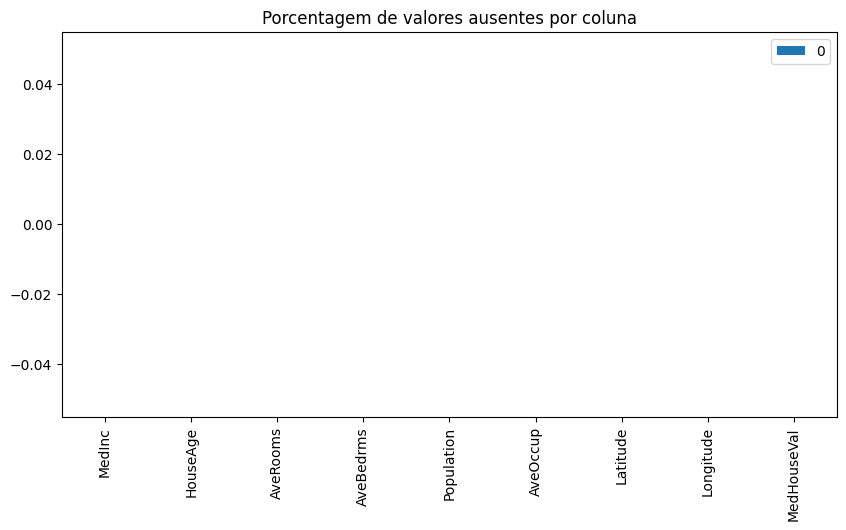

In [58]:
missing_values = df.isna().sum().div(df.shape[0]).to_frame().sort_values(by=0, ascending=False)
missing_values.plot(kind='bar', figsize=(10, 5))
plt.title('Porcentagem de valores ausentes por coluna')
plt.show()

In [59]:
correlations = df.corr()['MedHouseVal'].sort_values(ascending=False)
print(correlations)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


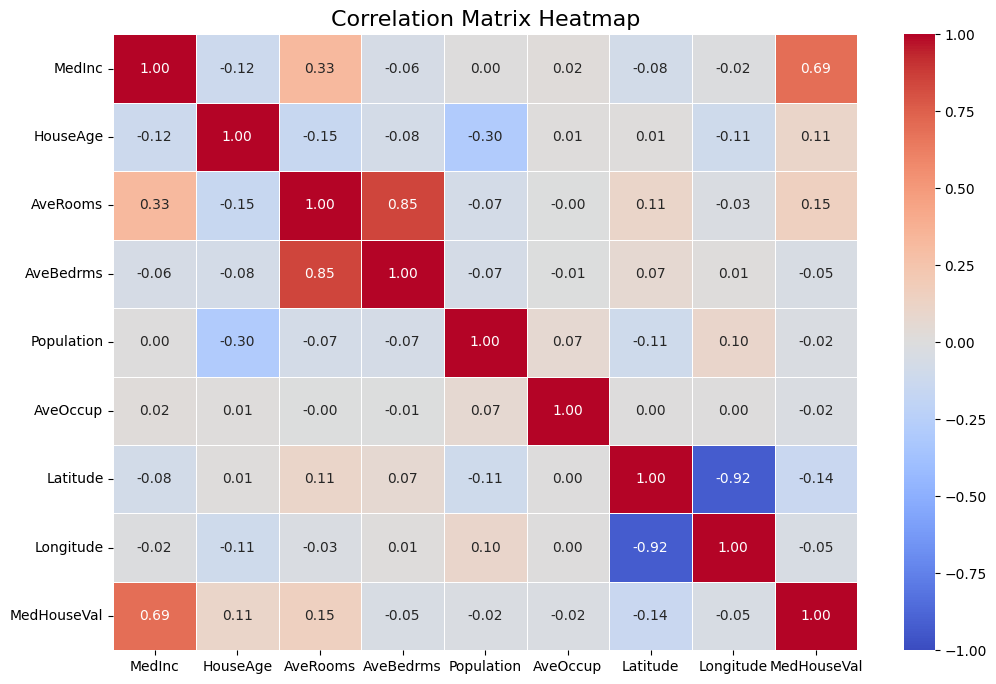

In [60]:
correlation_matrix = df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin = -1)
plt.title('Correlation Matrix Heatmap', fontsize=16)
plt.show()

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [62]:
# Preparando as variáveis para treinar o modelo.
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [64]:
model = ExtraTreesRegressor();
model.fit(X_train, y_train)

ExtraTreesRegressor()

In [65]:
# Fazer previsões
y_pred = model.predict(X_test)

# Calcular métricas
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'R² Score: {r2}')

Mean Absolute Error (MAE): 0.3268165439195738
Mean Squared Error (MSE): 0.253317439387379
Root Mean Squared Error (RMSE): 0.5033065064027873
R² Score: 0.8066882602350346


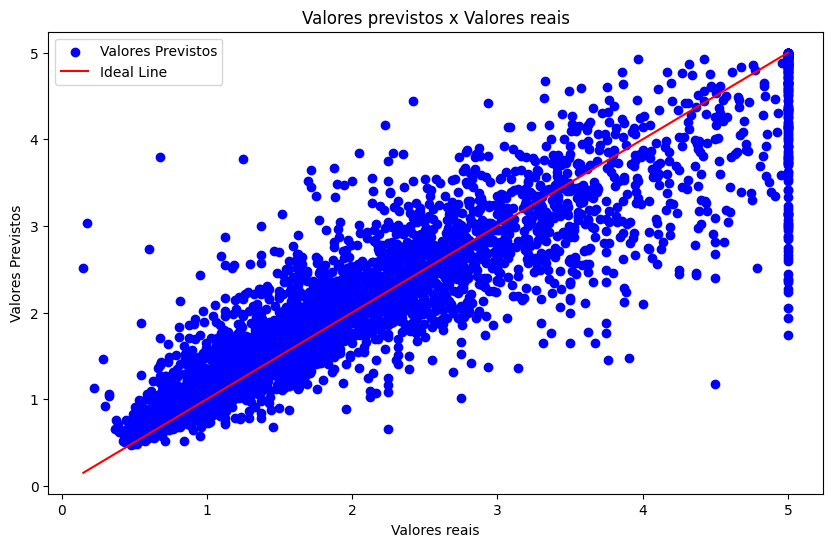

In [66]:
# Gráfico de valores previstos x valores atuais
plt.figure(figsize=(10, 6))
plt.scatter(x=y_test, y=y_pred, color='blue', label='Valores Previstos')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='-', label='Ideal Line')
plt.xlabel('Valores reais')
plt.ylabel('Valores Previstos')
plt.title('Valores previstos x Valores reais')
plt.legend()
plt.show()

In [67]:
print("Contagem de valores 5 em cada coluna:")
for column in df.columns:
    count_negative_200 = (df[column] == 5).sum()
    print(f"{column}: {count_negative_200}")

Contagem de valores 5 em cada coluna:
MedInc: 20
HouseAge: 244
AveRooms: 27
AveBedrms: 0
Population: 1
AveOccup: 1
Latitude: 0
Longitude: 0
MedHouseVal: 27


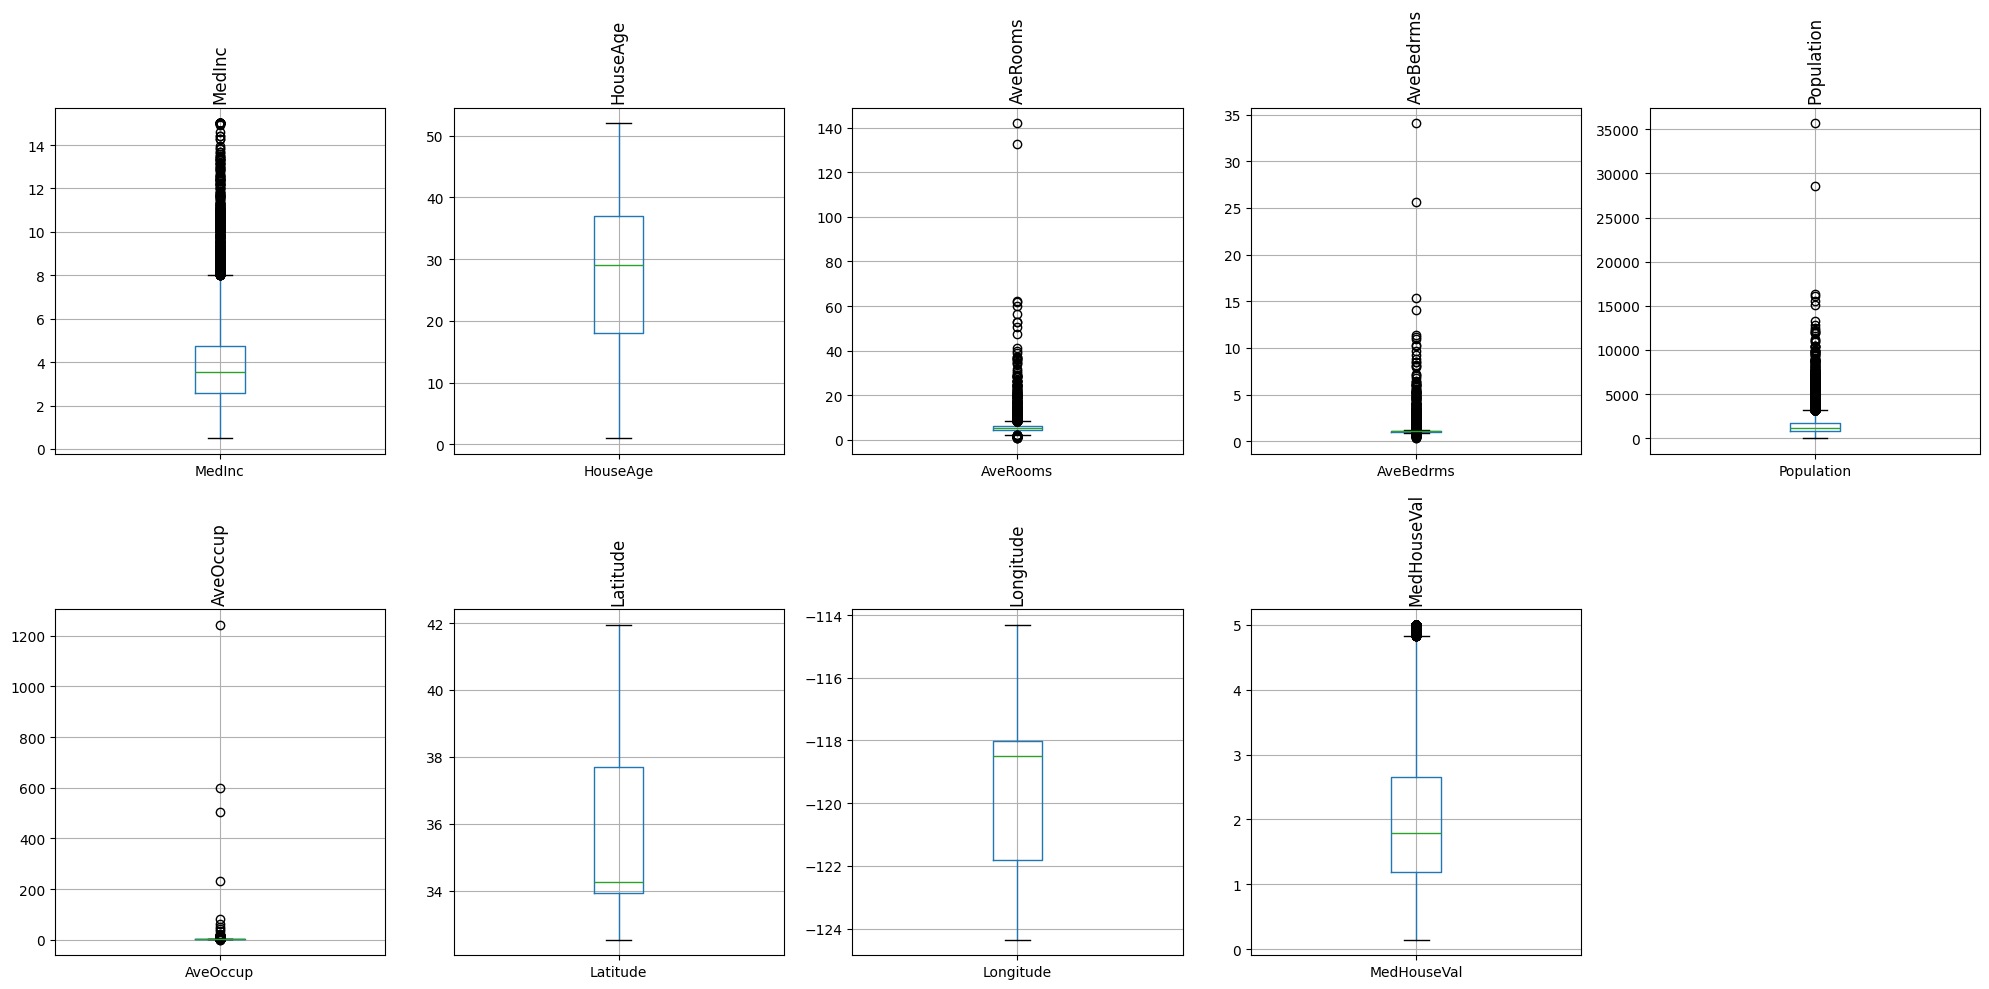

In [68]:
# Configuração da figura com subplots em duas linhas
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 10))

# Gerando os boxplots em subplots
for i, coluna in enumerate(df.columns):
    row = i // 5
    col = i % 5
    df.boxplot(column=coluna, ax=axes[row, col])
    axes[row, col].set_title(coluna, rotation=90)

# Se houver subplots vazios, desativá-los
for j in range(i + 1, 2 * 5):
    fig.delaxes(axes[j // 5, j % 5])

plt.tight_layout()
plt.show()

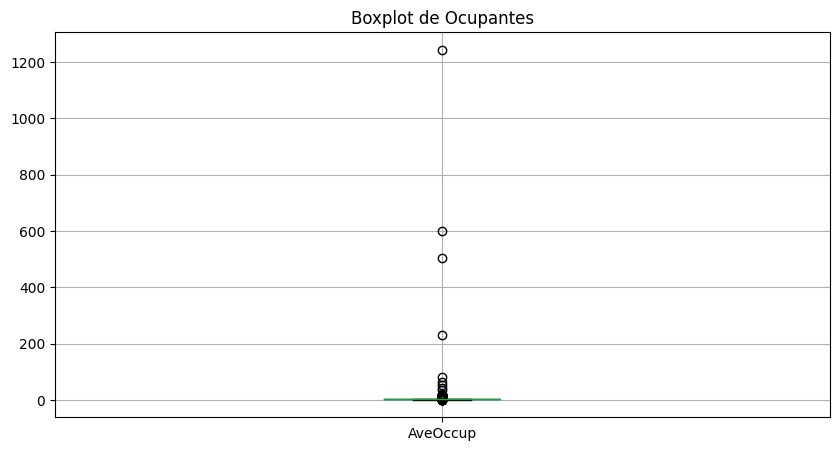

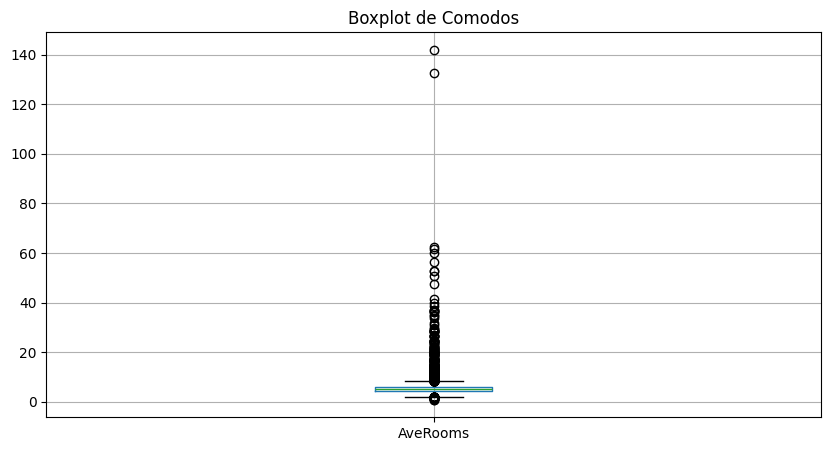

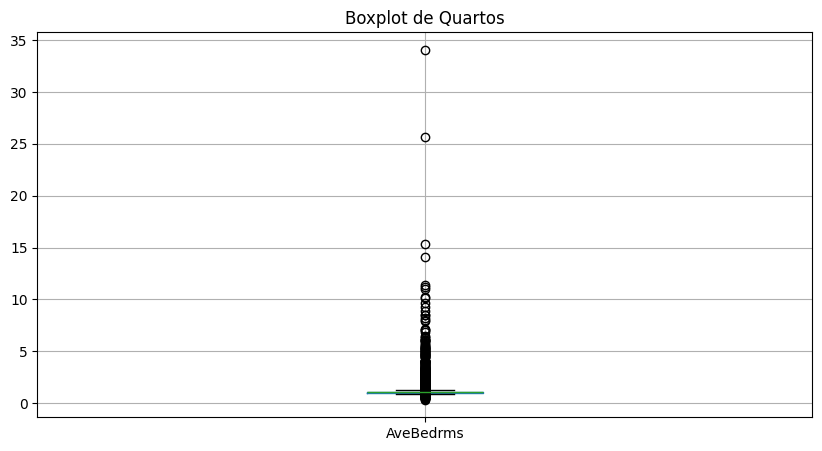

In [69]:
df.boxplot(column='AveOccup', figsize=(10, 5))
plt.title('Boxplot de Ocupantes')
plt.show()

df.boxplot(column='AveRooms', figsize=(10, 5))
plt.title('Boxplot de Comodos')
plt.show()

df.boxplot(column='AveBedrms', figsize=(10, 5))
plt.title('Boxplot de Quartos')
plt.show()

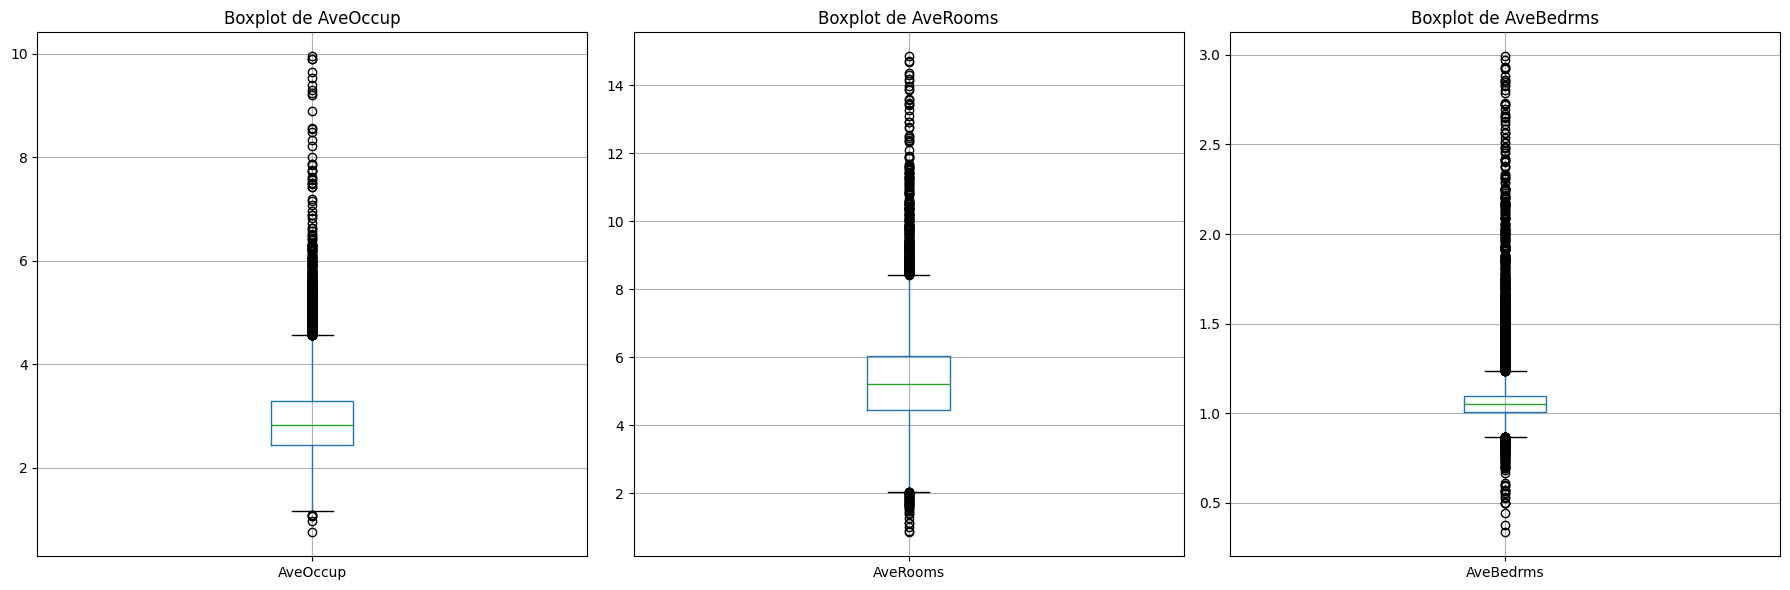

In [70]:
# Aplicando os filtros ao DataFrame original
df_filtered = df[(df['AveOccup'] <= 10) & (df['AveRooms'] <= 15) & (df['AveBedrms'] <= 3)]

# Configuração da figura com subplots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

# Plotando os boxplots separados
df_filtered.boxplot(column='AveOccup', ax=axes[0])
axes[0].set_title('Boxplot de AveOccup')

df_filtered.boxplot(column='AveRooms', ax=axes[1])
axes[1].set_title('Boxplot de AveRooms')

df_filtered.boxplot(column='AveBedrms', ax=axes[2])
axes[2].set_title('Boxplot de AveBedrms')

plt.tight_layout()
plt.show()